# Classification USe Case (Weather Classification)

## Business Problem -
- The goal is to accurately classify weather conditions (Rainy, Sunny, Cloudy, Snowy) based on various environmental factors such as temperature, humidity, wind speed, and atmospheric conditions.
- As this helps in : Weather forecasting systems, Agriculture planning, Travel & logistics optimization

## ML Probelm Statement - Supervised Learning (Multi-class Classification Problem) -
- Given a dataset containing multiple weather-related features, the task is to build a machine learning model that can predict the Weather Type category.


## Data Understanding -

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('data/weather_classification_data.csv')
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [13]:
## Shape fo the data

df.shape

(13200, 11)

In [15]:
## Info of the data

df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [16]:
df.columns

# (We dont have any extra spaces, so we dont need to strip those.)

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [19]:
## Summary statistics for numerical features

df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [20]:
## Summary statistics for categorical features

df.describe(include=['object'])

,Cloud Cover,Season,Location,Weather Type
count,13200,13200,13200,13200
unique,4,4,3,4
top,overcast,Winter,inland,Rainy
freq,6090,5610,4816,3300


In [22]:
## Cecking for missing value if any -

df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [23]:
## Checking whether the target variable is balanced or not -

df['Weather Type'].value_counts()

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

In [24]:
## Checking for duplicate rows

df.duplicated().sum()

np.int64(0)

In [29]:
df['Temperature'].value_counts()

Temperature
32.0     391
24.0     375
26.0     372
30.0     370
22.0     365
        ... 
102.0      1
86.0       1
108.0      1
87.0       1
95.0       1
Name: count, Length: 126, dtype: int64

In [31]:
df['Humidity'].value_counts()

Humidity
76     313
60     309
67     295
63     291
70     288
      ... 
100     46
102     42
109     42
103     41
101     36
Name: count, Length: 90, dtype: int64

In [32]:
df['Cloud Cover'].value_counts()

# (We have only 3 unique values in the 'Cloud Cover' column, with overcast having more data points than the other two.)

Cloud Cover
overcast         6090
partly cloudy    4560
clear            2139
cloudy            411
Name: count, dtype: int64

In [33]:
df['Season'].value_counts()

# (We have only 4 unique values in the 'Season' column, with Winter having more data points than the other three.)

Season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64

In [34]:
df['Location'].value_counts()

# (We have only 3 unique values in the 'Location' column, with Inland having more data points than the other two.)

Location
inland      4816
mountain    4813
coastal     3571
Name: count, dtype: int64

In [30]:
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

### Observation -
- Dataset contains 13,200 rows and 11 features including both numerical and categorical variables.
- There are no missing values in the dataet.
- Checked target variable distribution to ensure there is no class imbalance. Its perfectly balanced.
- There is no duplicate row present in the data.
- 126 unique temperature present in the data with 32.0 temperature contibuting more in the data followed by 24.0
- 90 unique humidity present in the data with '76' humidity contibuting more in the data followed by '60'.
- Cloud Cover has 3 unique values with 'overcast' contriuting more in the data.
- Season column has 4 unique values with 'winter' contriuting more in the data.
- Location column has 3 unique values with 'inland' contriuting more in the data.

## EDA

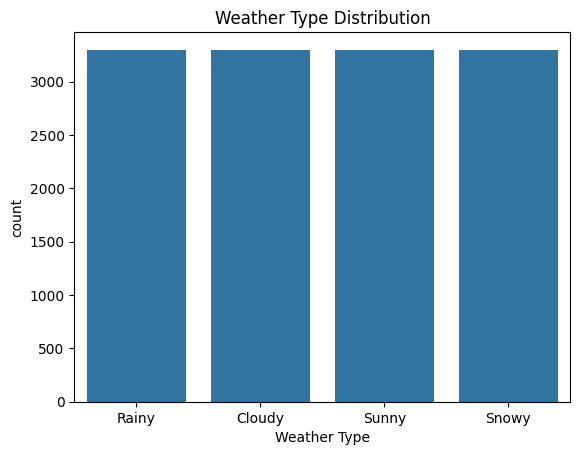

In [35]:
## Target variable distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Weather Type', data=df)
plt.title("Weather Type Distribution")
plt.show()

# (As we already checked this thta all the classes are balanced)

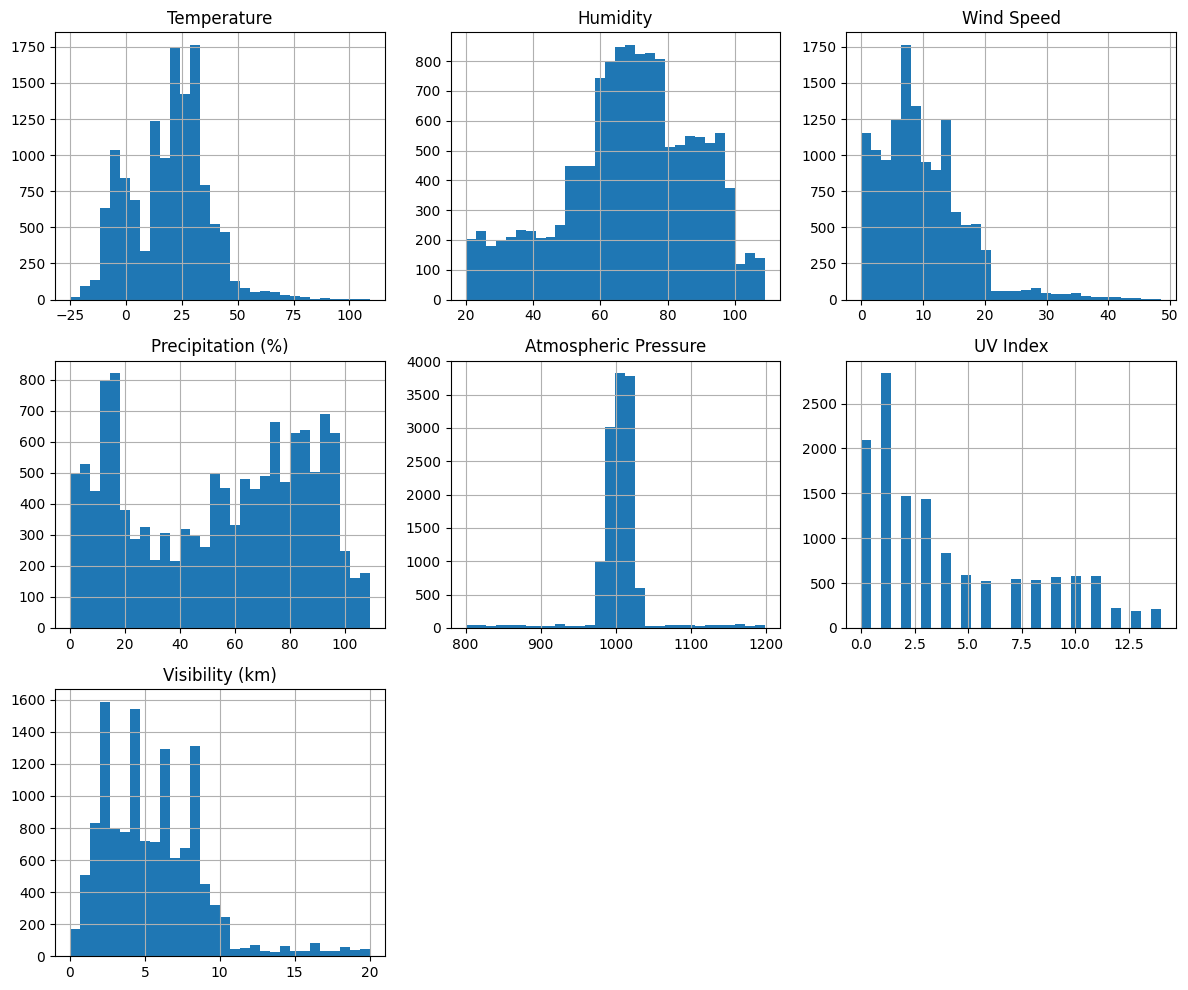

In [36]:
## Univariate Analysis

df.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

# (The histograms show that the 'Temperature' and 'Humidity' features have a somewhat normal distribution, while 'Wind Speed' has a right-skewed distribution.)

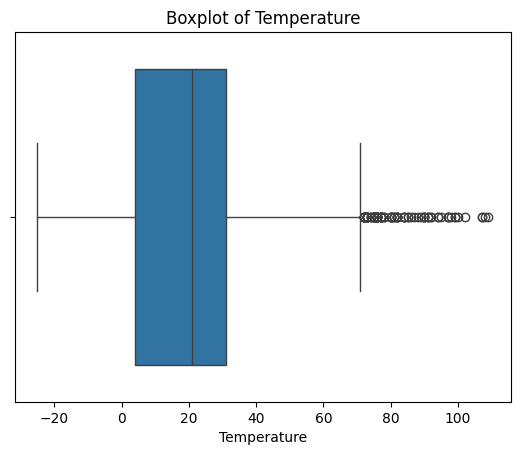

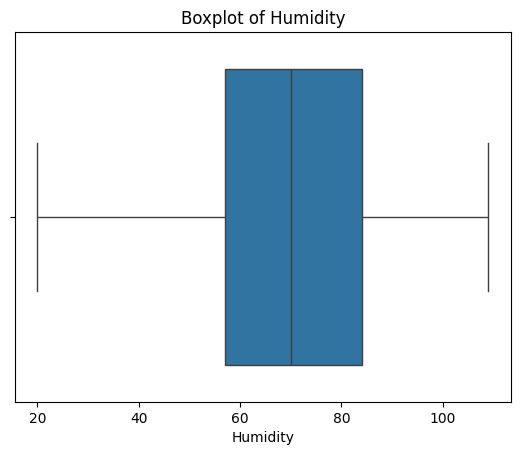

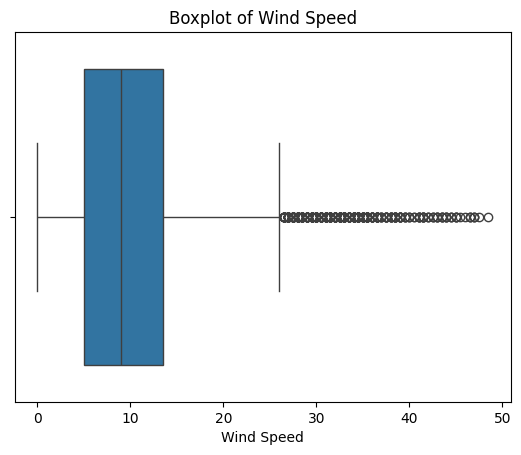

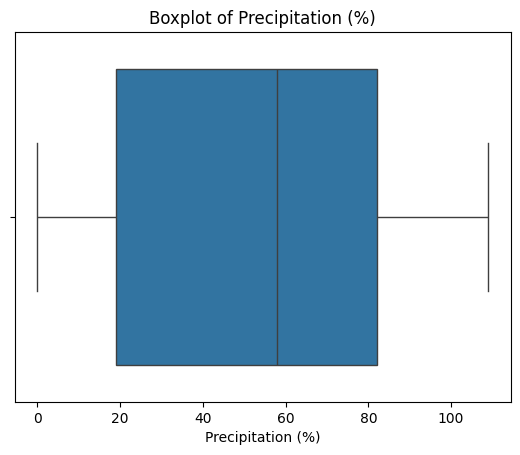

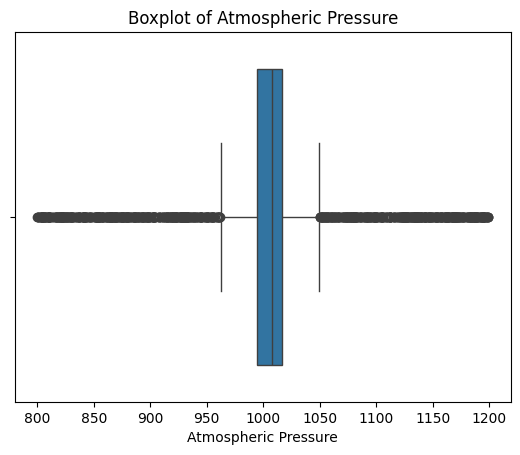

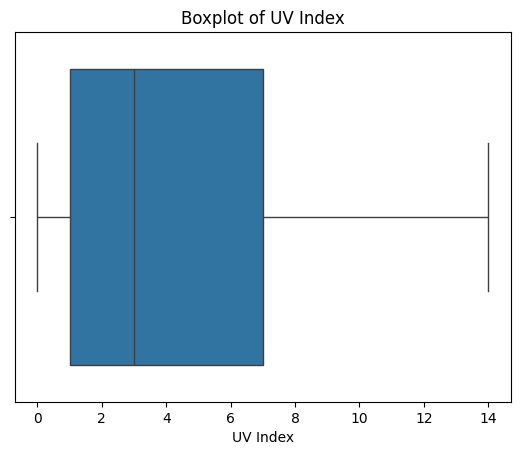

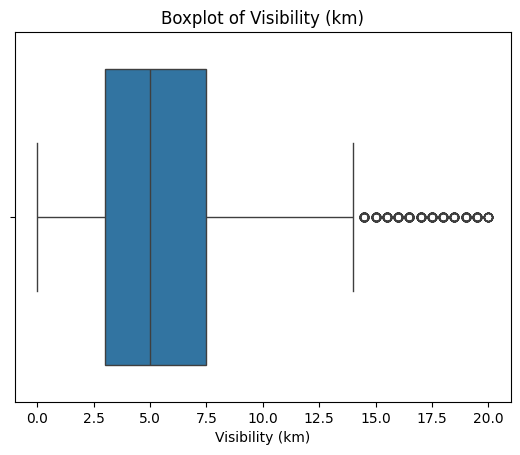

In [37]:
## Boxplots

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# (The boxplots show that there are some outliers in the 'Wind Speed', 'Temperature', 'Visibility' feature, which is consistent with the right-skewed distribution observed in the histogram. The 'Humidity', 'Precipitation' and 'UV Index' features do not show significant outliers.)

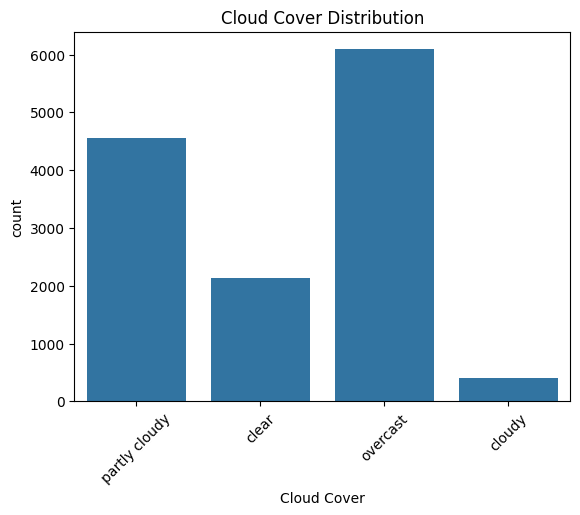

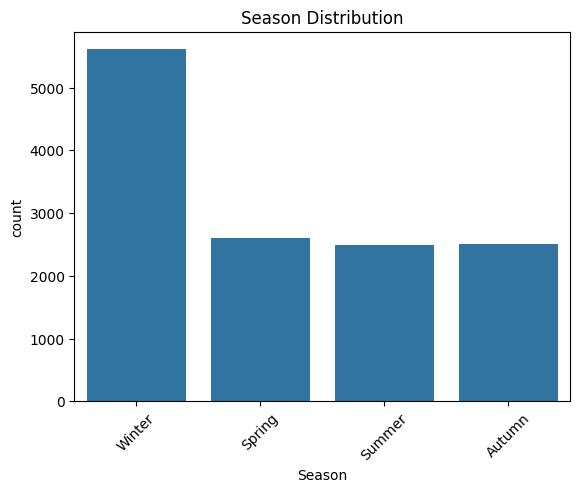

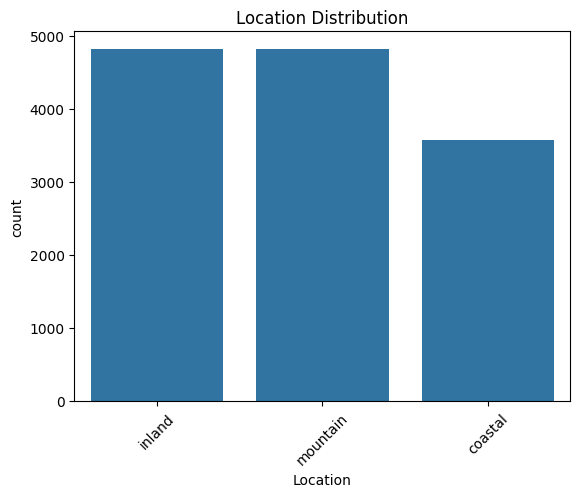

In [38]:
## Categorical Feature Analysis

cat_cols = ['Cloud Cover', 'Season', 'Location']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

# (The countplots show that 'Overcast' is the most common category in the 'Cloud Cover' feature, 'Winter' is the most common category in the 'Season' feature, and 'Inland' is the most common category in the 'Location' feature.)

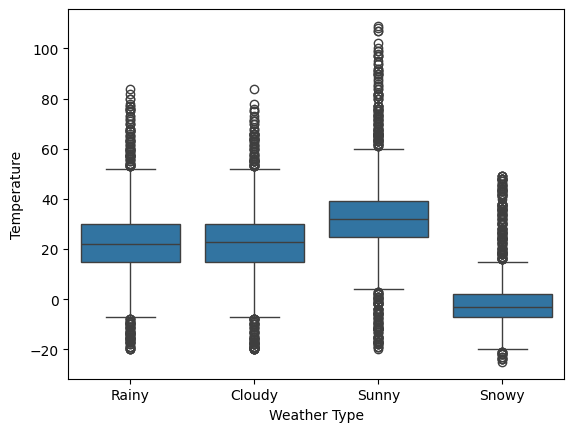

In [39]:
## Bivariate Analysis (Feature vs Target)

# Temperature vs Weather Type
sns.boxplot(x='Weather Type', y='Temperature', data=df)
plt.show()

# (The boxplot shows that the 'Temperature' feature has a different distribution for each 'Weather Type'. For example, 'Sunny' weather tends to have higher temperatures, while 'Snowy' weather tends to have lower temperatures. This suggests that 'Temperature' may be a useful feature for predicting 'Weather Type'.)

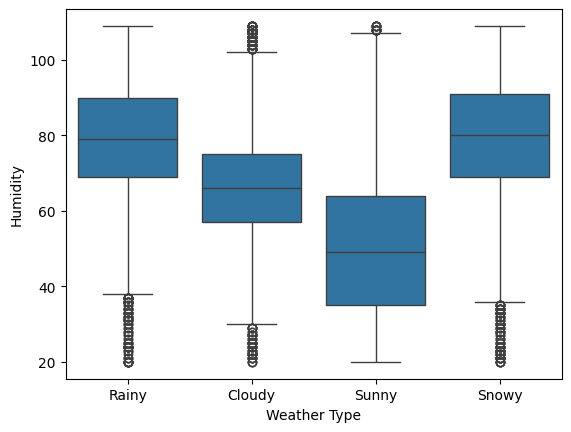

In [40]:
# Humidity vs Weather Type

sns.boxplot(x='Weather Type', y='Humidity', data=df)
plt.show()

# (The boxplot shows that the 'Humidity' feature also has a different distribution for each 'Weather Type'. For example, 'Rainy' weather tends to have higher humidity levels, while 'Sunny' weather tends to have lower humidity levels. This suggests that 'Humidity' may also be a useful feature for predicting 'Weather Type'.)

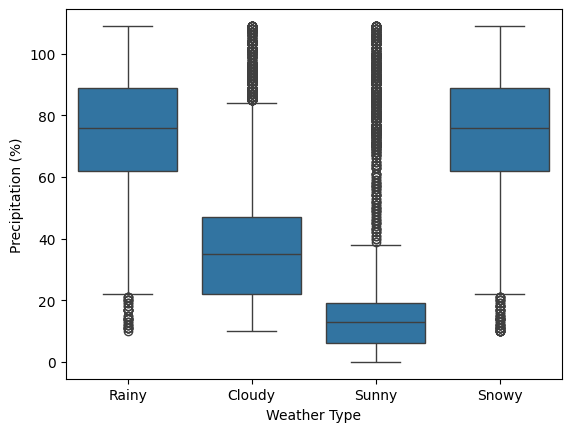

In [41]:
# Precipitation vs Weather Type

sns.boxplot(x='Weather Type', y='Precipitation (%)', data=df)
plt.show()

# (The boxplot shows that the 'Precipitation' feature also has a different distribution for each 'Weather Type'. For example, 'Rainy' weather tends to have higher precipitation levels, while 'Sunny' weather tends to have lower precipitation levels. This suggests that 'Precipitation' may also be a useful feature for predicting 'Weather Type'.)

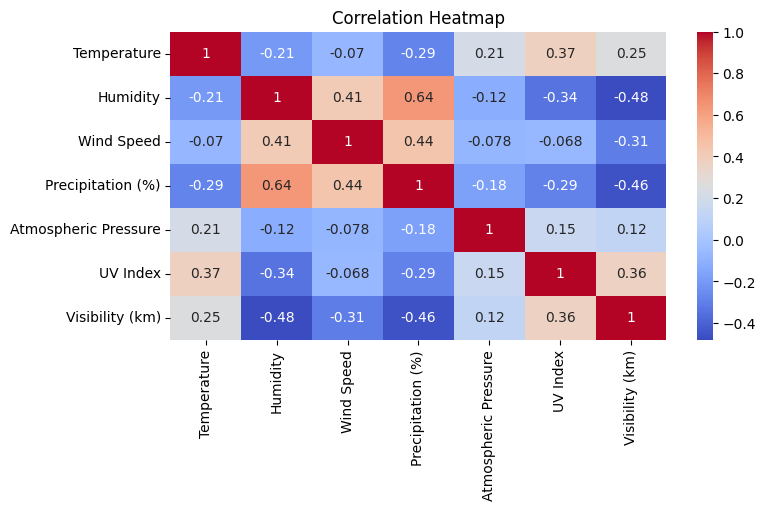

In [45]:
## Correlation Heatmap for numerical features

plt.figure(figsize=(8,4))
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# (The correlation heatmap shows that there are some moderate correlations between the numerical features. For example, 'Temperature' and 'Humidity' have a negative correlation, while 'Humidity' and 'Precipitation (%)' have a positive correlation. However, there are no extremely high correlations (above 0.8), which suggests that multicollinearity may not be a major issue in this dataset.)

### Observation -
- The dataset is perfectly balanced across all weather classes, so no class imbalance handling is required.
- The histograms show that the 'Temperature' and 'Humidity' features have a somewhat normal distribution, while 'Wind Speed' has a right-skewed distribution.
- Boxplots clearly confirm the presence of outliers in temperature, wind speed, atmospheric pressure and visibility.
- Categorical features show slight imbalance in categories like cloud cover and season.
- Temperature shows strong separation across weather types, making it an important predictive feature.
- Higher humidity is associated with rainy conditions.
- Rainy weather shows higher precipitation levels compared to other classes.
- Most features show low to moderate correlation, indicating minimal multicollinearity.

## Data Preprocessing and Feature Enginneeringng

In [110]:
## Separating Features and Target Variable

X = df.drop('Weather Type', axis=1)
y = df['Weather Type']


In [111]:
## Handling outliers

# Using IQR method to handle outliers in numerical features

# def cap_outliers(df, col):
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df[col] = df[col].clip(lower_bound, upper_bound)
#     return df

# num_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

# for col in num_cols:
#     X = cap_outliers(X, col)
# X


def get_outlier_bounds(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound

outlier_bounds = {}
num_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

for col in num_cols:
    lower, upper = get_outlier_bounds(X, col)
    outlier_bounds[col] = (lower, upper)
    X[col] = X[col].clip(lower, upper)

X


# (The outliers in the num_cols features have been capped using the IQR method. This should help to reduce the influence of extreme values on the model training process.
# Instead of removing the outliers, we have capped them to the upper and lower bounds calculated using the IQR method. This way, we retain all the data points while mitigating the impact of outliers on our model.)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
0,14.0,73,9.5,82.0,partly cloudy,1010.82000,2,Winter,3.5,inland
1,39.0,96,8.5,71.0,partly cloudy,1011.43000,7,Spring,10.0,inland
2,30.0,64,7.0,16.0,clear,1018.72000,5,Spring,5.5,mountain
3,38.0,83,1.5,82.0,clear,1026.25000,7,Spring,1.0,coastal
4,27.0,74,17.0,66.0,overcast,990.67000,1,Winter,2.5,mountain
...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15000,1,Summer,1.0,mountain
13196,-1.0,76,3.5,23.0,cloudy,1049.73125,1,Winter,6.0,coastal
13197,30.0,77,5.5,28.0,overcast,1012.69000,3,Autumn,9.0,coastal
13198,3.0,76,10.0,94.0,overcast,984.27000,0,Winter,2.0,inland


In [112]:
joblib.dump(outlier_bounds, "models/outlier_bounds.pkl")       # Saving this outlier bounds as ths can be used further in the inference pipeline
# joblib.dump(X.columns, "models/columns.pkl")                # Saving this columns so that this willbe used in the inference pipleine


['models/outlier_bounds.pkl']

In [113]:
## Handling categorical features using one-hot encoding

X = pd.get_dummies(X, columns=['Cloud Cover', 'Season', 'Location'], drop_first=True)
X
# (We have used one-hot encoding to convert the categorical features 'Cloud Cover', 'Season', and 'Location' into numerical format. The 'drop_first=True' parameter is used to 
# avoid the dummy variable trap by dropping the first category of each feature. This will help our machine learning model to better understand the relationships between the features and the target variable.
# One-hot encoding is used because the categorical variables are nominal (no inherent order). Label encoding would introduce incorrect ordinal relationships, which could negatively impact model performance.)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82000,2,3.5,False,False,True,False,False,True,True,False
1,39.0,96,8.5,71.0,1011.43000,7,10.0,False,False,True,True,False,False,True,False
2,30.0,64,7.0,16.0,1018.72000,5,5.5,False,False,False,True,False,False,False,True
3,38.0,83,1.5,82.0,1026.25000,7,1.0,False,False,False,True,False,False,False,False
4,27.0,74,17.0,66.0,990.67000,1,2.5,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15000,1,1.0,False,True,False,False,True,False,False,True
13196,-1.0,76,3.5,23.0,1049.73125,1,6.0,True,False,False,False,False,True,False,False
13197,30.0,77,5.5,28.0,1012.69000,3,9.0,False,True,False,False,False,False,False,False
13198,3.0,76,10.0,94.0,984.27000,0,2.0,False,True,False,False,False,True,True,False


In [114]:
joblib.dump(X.columns, "models/columns.pkl")                # Saving this columns so that this willbe used in the inference pipleine


['models/columns.pkl']

In [115]:
## Feature Scaling (Imprtant for algorithms like Logistic Regression, SVM, KNN which are distance-based)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Temperature', 'Humidity', 'Wind Speed', 
            'Precipitation (%)', 'Atmospheric Pressure', 
            'UV Index', 'Visibility (km)']

X[num_cols] = scaler.fit_transform(X[num_cols])
X.head()

# (We have applied standard scaling to the numerical features to ensure that they are on the same scale. This is important for distance-based algorithms, as it helps to improve the 
# performance of the model by preventing features with larger scales from dominating the learning process.)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,-0.295219,0.212404,-0.020104,0.887629,0.277477,-0.520104,-0.606213,False,False,True,False,False,True,True,False
1,1.166084,1.351385,-0.181037,0.543291,0.313030,0.776424,1.487185,False,False,True,True,False,False,True,False
2,0.640015,-0.233285,-0.422435,-1.178401,0.737919,0.257813,0.037909,False,False,False,True,False,False,False,True
3,1.107632,0.707613,-1.307562,0.887629,1.176797,0.776424,-1.411366,False,False,False,True,False,False,False,False
4,0.464659,0.261924,1.186887,0.386773,-0.896943,-0.779410,-0.928274,False,True,False,False,False,True,False,True


In [116]:
## Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# (We have split the dataset into a training set (80%) and a test set (20%). The 'random_state=42' parameter is used to ensure that the split is reproducible, meaning that we will get the same split every time we run the code.)

In [117]:
## Save Preprocessing Pipeline

import joblib

joblib.dump(scaler, "models/scaler.pkl")

# (We have saved the fitted scaler object using joblib so that we can use it later to transform new data in the same way as we did for the training data. This is important to ensure that the features of new data are scaled consistently with the training data when making predictions with our machine learning model.)

['models/scaler.pkl']

### Obervation -
- Outliers were handled using IQR-based capping so instead of deleting rows with extreme values, we clipped them to a reasonable range using the IQR, so the model doesn't get misled by unusual data points.
- Categorical variables were encoded using one-hot encoding to convert them into numerical format for model compatibility.
- Feature scaling was applied using StandardScaler to normalize feature ranges, especially important for distance-based models like KNN and SVM.
- Data was split into training and testing sets (80-20) to evaluate model generalization.

## Model Building

In [80]:
## Import required libraries for modeling

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [81]:
## Defining 5 models 

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [82]:
## Train + Evaluate All Models

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

# (We have trained and evaluated 5 different machine learning models on our dataset. The classification report for each model provides detailed metrics for each class, which can help us understand the performance of the models on different weather types.)
# Here, each row shows performance for a class (cloudy, rainy, etc..)

# Each metric:
    # Precision -> Out of predicted class, how many were correct (Considering below Log Reg result - When model predicts Cloudy, 83% are correct.)
    # Recall -> Out of actual class, how many were correctly identified (Considering below Log Reg result - Out of all actual Cloudy cases,85% were captured)
    # F1-score -> Balance between precision & recall
    # Support -> Number of actual samples (In the test set)

    # Macro average -> Treats all classes equally. Average of precision, recall, f1-score across all classes without considering class imbalance.
    # Weighted average -> Weights based on class size like it takes into account class imbalance. Average of precision, recall, f1-score across all classes weighted by the number of samples in each class.
    # Since our data is perfectly balanced hence macro average ~ weighted average


Logistic Regression
              precision    recall  f1-score   support

      Cloudy       0.83      0.85      0.84       651
       Rainy       0.86      0.85      0.85       647
       Snowy       0.89      0.94      0.91       701
       Sunny       0.92      0.86      0.89       641

    accuracy                           0.87      2640
   macro avg       0.87      0.87      0.87      2640
weighted avg       0.87      0.87      0.87      2640


Decision Tree
              precision    recall  f1-score   support

      Cloudy       0.90      0.89      0.89       651
       Rainy       0.88      0.90      0.89       647
       Snowy       0.93      0.95      0.94       701
       Sunny       0.93      0.90      0.91       641

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640


Random Forest
              precision    recall  f1-score   support

      Cloudy       0.88 

In [83]:
## Create Comparison Table

results_df = pd.DataFrame(results)
results_df.sort_values(by='F1 Score', ascending=False)

# Here, we are mainly looking for accuracy and f1 score.
# Why not focusing on precision and recall ?
    # Reason 1 -
    # Balanced Dataset
    # All classes = 3300 samples
    # No class imbalance
    # So, Precision & Recall don’t create conflicting trade-offs.    

    # Reason 2 -
    #  No Critical Business Risk
    # Precision/Recall matter when:
        # Scenario	        Important Metric
        # Fraud detection	Recall (don’t miss fraud)
        # Spam detection	Precision (don’t misclassify real emails)

# Why Accuracy is Important Here
# Accuracy works well when:
    # Dataset is balanced. 
    # All classes are equally important. 
    # So, Accuracy gives a good overall picture.

# Why F1-Score is aslo important
    # Even though dataset is balanced:
    # F1-score ensures:
    # Model is not biased toward one metric
    # Balance between precision & recall

# Key Logic
    # Accuracy tells “how many correct”.
    # F1-score tells “how well balanced the predictions are”.

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.914015,0.914316,0.914015,0.914094
3,SVM,0.911364,0.911553,0.911364,0.911430
1,Decision Tree,0.909091,0.909196,0.909091,0.909062
4,KNN,0.899621,0.900535,0.899621,0.899817
0,Logistic Regression,0.873485,0.874180,0.873485,0.873348


### Observation -
- Logistic Regression - Lowest performance -> linear limitation.
- Decision Tree - Good performance but risk of overfitting.
- Random Forest - Strong & stable and also handles variance well.
- SVM - Also strong -> good boundary separation.
- KNN - Slightly lower also sensitive to neighbors & scaling.
- Since the dataset is balanced, accuracy is a reliable metric for evaluation. However, I also considered F1-score to ensure a balance between precision and recall. Based on the results, Random Forest and SVM performed best with consistent scores across all classes.

### Hyper Parameter Tuning (Using GridSearch CV and RandomizedSearchCV)

In [ ]:
## GridSearchCV (Exhaustive Search)
# Tries ALL possible combinations of hyperparameters
# Example:
    # n_estimators = [100, 200]
    # max_depth = [10, 20]
    # Total combinations = 2 × 2 = 4
    # Checks all 4 combinations

# Pros:
    # Finds best possible combination
    # More thorough
# Cons:
    # Very slow
    # Not scalable for large datasets


## RandomizedSearchCV (Random Search)
# Tries random combinations from parameter space
# Example:
    # Same params, but:
    # I fwe set n_iter = 3
    # It will randomly try only 3 combinations (not all)

# Pros:
    # Much faster
    # Works well for large datasets
    # Often gives near-optimal results
# Cons:
    # May miss the absolute best combination

# Key Difference:
    # GridSearchCV = Exhaustive search
    # RandomizedSearchCV = Smart sampling

# When to Use What?
# Scenario	                Use
# Small dataset	        GridSearchCV
# Large dataset	        RandomizedSearchCV
# Time constraint	    RandomizedSearchCV
# Need best accuracy	GridSearchCV

In [84]:
## Grid Search CV - Random Forest

from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Params RF:", grid_rf.best_params_)

Best Params RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [85]:
## GridSearchCV - SVM

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC()

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best Params SVM:", grid_svm.best_params_)

Best Params SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [86]:
# RandomizedSearchCV - Random Forest

from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=10,  # number of random combinations
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

random_rf.fit(X_train, y_train)

print("Best Params RF:", random_rf.best_params_)

Best Params RF: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30}


In [87]:
# RandomizedSearchCV - SVM

param_dist_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svm = SVC()

random_svm = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist_svm,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

random_svm.fit(X_train, y_train)

print("Best Params SVM:", random_svm.best_params_)

Best Params SVM: {'kernel': 'rbf', 'gamma': 'auto', 'C': 10}


In [89]:
## Now training final models with best params
# For RandomForest Choosing RandomizedSearchCV params as its trying to reduce overfitting (max_depth=30) where as in GridSearchCV its None
# And for SVM both RandomizedSearchCV and GridSearchCV have given same params

# Final Random Forest 
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=4,
    random_state=42
)

# Final SVM
svm_final = SVC(
    C=10,
    gamma='auto',
    kernel='rbf'
)

## Evaluating again -
rf_final.fit(X_train, y_train)
svm_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)
y_pred_svm = svm_final.predict(X_test)

print("Random Forest Final")
print(classification_report(y_test, y_pred_rf))

print("SVM Final")
print(classification_report(y_test, y_pred_svm))

Random Forest Final
              precision    recall  f1-score   support

      Cloudy       0.89      0.90      0.89       651
       Rainy       0.91      0.92      0.91       647
       Snowy       0.95      0.94      0.94       701
       Sunny       0.93      0.92      0.92       641

    accuracy                           0.92      2640
   macro avg       0.92      0.92      0.92      2640
weighted avg       0.92      0.92      0.92      2640

SVM Final
              precision    recall  f1-score   support

      Cloudy       0.87      0.89      0.88       651
       Rainy       0.88      0.90      0.89       647
       Snowy       0.94      0.94      0.94       701
       Sunny       0.94      0.90      0.92       641

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



### Observation -
- After hyperparameter tuning, I evaluated both Random Forest and SVM. While both models showed similar performance, I selected Random Forest because it provides better interpretability, robustness to outliers, and faster inference compared to SVM.

In [ ]:
## Saving the model -
# Scaler, outlier bounds and columns were already saved so now saving final ml model 

joblib.dump(rf_final, "models/rf_weather_model.pkl")


['models/rf_weather_model.pkl']

## Inference pipeline

In [118]:
# Load saved artifacts

model = joblib.load("models/rf_weather_model.pkl")
scaler = joblib.load("models/scaler.pkl")
columns = joblib.load("models/columns.pkl")
outlier_bounds = joblib.load("models/outlier_bounds.pkl")

num_cols = ['Temperature', 'Humidity', 'Wind Speed', 
            'Precipitation (%)', 'Atmospheric Pressure', 
            'UV Index', 'Visibility (km)']

def predict_weather(input_data):
    
    # Step 1: Convert input to DataFrame
    df = pd.DataFrame([input_data])
    
    # Step 2: Handle outliers using saved bounds
    for col in num_cols:
        lower, upper = outlier_bounds[col]
        df[col] = df[col].clip(lower, upper)
    
    # Step 3: One-hot encoding
    df = pd.get_dummies(df)
    
    # Step 4: Align columns with training data
    df = df.reindex(columns=columns, fill_value=0)
    
    # Step 5: Feature Scaling
    df[num_cols] = scaler.transform(df[num_cols])
    
    # Step 6: Prediction
    prediction = model.predict(df)
    
    return prediction[0]

In [130]:
sample_input = {
    "Temperature": -8,
    "Humidity": 63,
    "Wind Speed": 0.5,
    "Precipitation (%)": 73,
    "Cloud Cover": "overcast",
    "Atmospheric Pressure": 994,
    "UV Index": 1,
    "Season": "Winter",
    "Visibility (km)": 3,
    "Location": "mountain"
}

print(predict_weather(sample_input))

Snowy


In [132]:
df.sample(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
12991,17.0,95,6.5,107.0,clear,1028.12,14,Summer,8.5,mountain,Sunny
9145,14.0,62,6.0,96.0,overcast,1006.55,3,Autumn,4.0,mountain,Rainy


### Observation -
- I built an inference pipeline that ensures consistency between training and prediction phases by reusing saved preprocessing artifacts like scaler, feature columns, and outlier bounds. This ensures reliable predictions in real-world scenarios.